# Visualizando Gargalos e Cenários Críticos da Intermitência Renovável (2024-2025)

---


#### Vitória Emanuele de Sousa Silva | contato: vitoriaemanueledesousa@gmail.com


---



**I. Escopo:** O projeto se insere no campo da operação e planejamento do setor elétrico, com foco em analisar os impactos da intermitência de energias renováveis (eólica e fotovoltaica) durante o biênio 2024-2025. A análise de dados foi utilizada para identificar gargalos operacionais e cenários críticos de estresse na rede, destacando o fenômeno da 'Curva do Pato' e a alta estocasticidade da geração eólica, oferecendo insights visuais para apoiar a tomada de decisão no despacho de energia e garantir a segurança do Sistema Interligado Nacional (SIN).

**II. Desafio:** O desafio enfrentado é a dificuldade em prever e manejar antecipadamente os momentos de instabilidade na rede elétrica, devido à alta penetração e intermitência das fontes renováveis no Nordeste. A ausência de uma visão clara sobre os gargalos operacionais, como o descompasso da 'Curva do Pato' (queda solar) e a alta volatilidade estocástica dos ventos, dificultava a tomada de decisões preventivas focadas no despacho seguro de energia. O projeto busca resolver este problema por meio de visualizações que destacam os cenários críticos de estresse e as janelas de vulnerabilidade do Sistema Interligado Nacional (SIN).

**III. Mapeamento dos dados e Visualização :**

In [26]:
import pandas as pd
import matplotlib.pyplot as plt


Os datasets anuais do ONS (2024 e 2025) são carregados individualmente para permitir uma validação inicial de integridade.

In [27]:
df_2024 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2024.csv', sep=';')

# Create a DataFrame to display column information in a more structured way
column_info = pd.DataFrame({
    'Column Name': df_2024.columns,
    'Data Type': df_2024.dtypes,
    'Non-Null Count': df_2024.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,43920
1,nom_subsistema,str,43920
2,din_instante,str,43920
3,val_gerhidraulica,float64,43920
4,val_gertermica,float64,43920
5,val_gereolica,float64,43920
6,val_gersolar,float64,43920
7,val_carga,float64,43920
8,val_intercambio,float64,43920


In [28]:
df_2025 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2025.csv', sep=';')

column_info = pd.DataFrame({
    'Column Name': df_2025.columns,
    'Data Type': df_2025.dtypes,
    'Non-Null Count': df_2025.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,43800
1,nom_subsistema,str,43800
2,din_instante,str,43800
3,val_gerhidraulica,float64,43800
4,val_gertermica,float64,43800
5,val_gereolica,float64,43800
6,val_gersolar,float64,43800
7,val_carga,float64,43800
8,val_intercambio,float64,43800



### 1.2 Dicionário de Variáveis (Dataset ONS)

Para este estudo de caso, as colunas foram interpretadas conforme as definições técnicas do Operador Nacional do Sistema (ONS):

* **`din_instante`**: Representa a marca temporal (data e hora) do registro.

* **`val_gerhidraulica`**: Total de energia gerada por usinas hídricas no subsistema (em MWmed).

* **`val_gertermica`**: Energia gerada por fontes térmicas (fósseis ou biomassa). Geralmente usada como base ou backup do sistema.

* **`val_gereolica`**: Potência gerada a partir da força dos ventos, principal fonte de exportação do Nordeste.

* **`val_gersolar`**: Geração fotovoltaica. É a fonte que apresenta a maior variação cíclica (dia/noite) e define a "curva do pato".

* **`val_carga`**: Representa a demanda ou consumo de energia da região naquele instante. É a linha que o sistema precisa sempre "atender".

* **`val_intercambio`**: Saldo líquido de energia. Valores positivos indicam que o Nordeste está exportando excedente para outras regiões; valores negativos indicam importação para suprir a demanda local.



### 1.3 :

As bases de dados foram concatenadas em um único DataFrame unificado, garantindo a continuidade da série temporal. Utilizou-se o parâmetro `ignore_index=True` para reorganizar os índices e evitar duplicidades.

In [40]:
df = pd.concat([df_2024, df_2025], ignore_index=True)

column_info = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,87720
1,nom_subsistema,str,87720
2,din_instante,str,87720
3,val_gerhidraulica,float64,87720
4,val_gertermica,float64,87720
5,val_gereolica,float64,87720
6,val_gersolar,float64,87720
7,val_carga,float64,87720
8,val_intercambio,float64,87720


Conversão da coluna `din_instante` para o formato ***datetime***. Além disso, extrai as colunas de 'Ano' e 'Mês', facilitando filtros temporais e análises comparativas posteriores.

In [41]:
# Converte para datetime
df['din_instante'] = pd.to_datetime(df['din_instante'])

# Extrai ano e mês (Feature Engineering básica)
df['ano'] = df['din_instante'].dt.year
df['mes'] = df['din_instante'].dt.month

column_info = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,87720
1,nom_subsistema,str,87720
2,din_instante,datetime64[us],87720
3,val_gerhidraulica,float64,87720
4,val_gertermica,float64,87720
5,val_gereolica,float64,87720
6,val_gersolar,float64,87720
7,val_carga,float64,87720
8,val_intercambio,float64,87720
9,ano,int32,87720


1.4: Matriz energetica Brasileira:

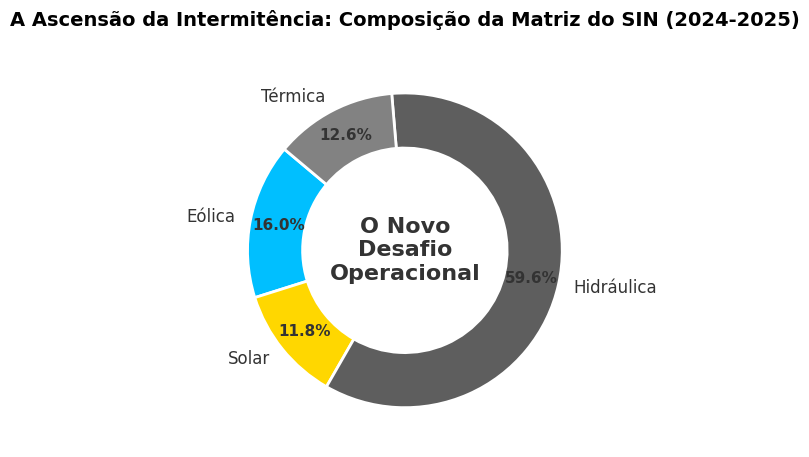

In [42]:

df_sin = df[df['id_subsistema'] == 'SIN']

# somar o total gerado por cada fonte de 2024-2025
total_hidraulica = df_sin['val_gerhidraulica'].sum()
total_termica = df_sin['val_gertermica'].sum()
total_eolica = df_sin['val_gereolica'].sum()
total_solar = df_sin['val_gersolar'].sum()

fontes = ['Eólica', 'Solar', 'Hidráulica', 'Térmica']
valores = [total_eolica, total_solar, total_hidraulica, total_termica]

# paleta de cores estrategica (principio do foco visual)
cores = ['#00BFFF', '#FFD700', '#5e5e5e', '#828282'] 

# construcao da Figura
fig, ax = plt.subplots(figsize=(5, 5))


wedges, texts, autotexts = ax.pie(valores, labels=fontes, autopct='%1.1f%%', 
                                  startangle=140, colors=cores, pctdistance=0.82, 
                                  wedgeprops=dict(width=0.35, edgecolor='white', linewidth=2))

# Estilização das fontes
plt.setp(autotexts, size=11, weight="bold", color="#333333")
plt.setp(texts, size=12, color="#333333")

# 5. Título com Storytelling (Destacando a mensagem central) [1]
plt.title('A Ascensão da Intermitência: Composição da Matriz do SIN (2024-2025)', 
          fontsize=14, weight='bold', pad=20)

# 6. Anotação Central: Entrega o insight de urgência de forma clara [1]
ax.text(0, 0, 'O Novo\nDesafio\nOperacional', ha='center', va='center', 
        fontsize=16, weight='bold', color='#333333')

plt.tight_layout()
plt.show()